[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/07_improper_integrals_special_functions/first_principles.ipynb)

# Module 07 — Improper Integrals and Special Functions

## 1. Why This Module Exists

The Riemann integral $\int_a^b f(x) \, dx$ is defined for a **bounded** function on a **compact** interval. Two of the most useful integrals in applied mathematics satisfy neither condition. A probability density on $\mathbb{R}$ is integrated over an unbounded domain; the Beta density $\theta^{a-1}(1-\theta)^{b-1}$ with $a \lt 1$ blows up at $\theta = 0$. Neither object is a Riemann integral at all until the definition is extended.

The extension is a limit: integrate over a compact piece, then let the piece exhaust the domain. Everything downstream depends on one question — **does that limit exist and is it finite?** A density that fails to converge has no normalizing constant, a moment that fails to converge is not a number, and a variational bound built on a divergent integral is meaningless.

The limit also creates two genuinely new phenomena that do not occur for proper integrals. First, an integral can converge while its absolute value diverges, so the value depends on cancellation rather than on accumulated area. Second, a symmetric limit can exist when the two one-sided limits do not, which is the Cauchy principal value — a strictly weaker notion that is easy to confuse with convergence.

Once the limit is under control, two functions defined *by* improper integrals — the Gamma function $\Gamma$ and the Beta function $B$ — turn out to be the normalizing constants of the Gamma, Beta, chi-squared, Student-$t$ and Dirichlet laws, the volume of the $d$-ball, and the Feynman parameterization used to combine propagator denominators in quantum field theory. This module builds the convergence theory first and then those two functions on top of it.

## 2. Intuition

Picture the area under $y = x^{-p}$ from $1$ out to a moving right edge $R$, and call it $A(R) = \int_1^R x^{-p} \, dx$. The function $A$ is increasing in $R$ because the integrand is positive; the only question is whether it is **bounded**. An increasing bounded function has a limit, an increasing unbounded one does not. That single dichotomy is the whole convergence theory for non-negative integrands.

The competition is between how fast the curve falls and how much room the axis gives it. At $p = 2$ the curve falls fast enough that the accumulated area saturates at $1$. At $p = 1/2$ it falls too slowly and the area grows without bound. At exactly $p = 1$ the area grows like $\ln R$ — divergent, but only just, which is why $1/x$ is the knife edge every comparison test is calibrated against.

Reading the same picture from the other end gives the Type II theory. Near $x = 0$ the graph of $x^{-p}$ is a vertical spike, and now a *large* $p$ is fatal: the spike is too tall to have finite area once $p \ge 1$. The two $p$-tests are mirror images — $p \gt 1$ wins at infinity, $p \lt 1$ wins at the origin — and no single power $x^{-p}$ is integrable on all of $(0, \infty)$.

Oscillation breaks this picture. For $\sin(x)/x$ the area alternates in sign, so $A(R)$ is no longer increasing; it converges because successive lobes nearly cancel, not because the total area is finite. That distinction between accumulation and cancellation is what separates absolute from conditional convergence.

The first code cell fixes the plotting style and the random generator used everywhere below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

**Figure 1** draws the accumulated-area function $A(R) = \int_1^R x^{-p} \, dx$ for the three regimes $p \lt 1$, $p = 1$ and $p \gt 1$, together with the horizontal asymptote $1/(p-1)$ predicted by Theorem 4.1 for the convergent case.

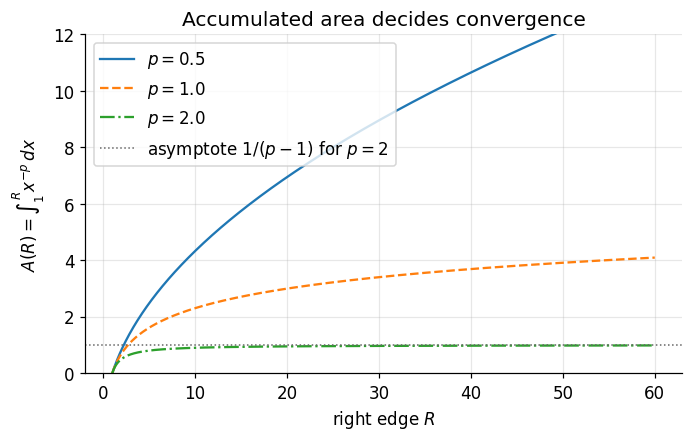

A(60): {0.5: 13.4919, 1.0: 4.0943, 2.0: 0.9833}


In [2]:
R = np.linspace(1.0, 60.0, 800)

def area(R, p):
    """Exact A(R) = int_1^R x^{-p} dx, the accumulated area out to the moving edge R."""
    return np.log(R) if np.isclose(p, 1.0) else (R**(1.0 - p) - 1.0) / (1.0 - p)

fig, ax = plt.subplots()
for p, style in [(0.5, "-"), (1.0, "--"), (2.0, "-.")]:
    ax.plot(R, area(R, p), style, label=rf"$p={p}$")
ax.axhline(1.0 / (2.0 - 1.0), color="0.4", lw=1, ls=":",
           label=r"asymptote $1/(p-1)$ for $p=2$")
ax.set_xlabel(r"right edge $R$")
ax.set_ylabel(r"$A(R)=\int_1^R x^{-p}\,dx$")
ax.set_title("Accumulated area decides convergence")
ax.set_ylim(0, 12)
ax.legend()
plt.show()

print("A(60):", {p: round(float(area(np.array(60.0), p)), 4) for p in (0.5, 1.0, 2.0)})

The $p = 2$ curve is already flat at $A \approx 0.98$ and is pinned under $1$ forever; the $p = 1$ curve is still climbing like $\ln R$; the $p = 1/2$ curve climbs like $2\sqrt{R}$. Boundedness of an increasing $A$, not the decay of the integrand on its own, is what convergence means.

## 3. Definitions

Throughout, $f$ is assumed Riemann-integrable on every compact subinterval of the stated domain, so that each truncated integral below is an ordinary Riemann integral.

### Definition 3.1 (Type I, infinite upper limit)

For $f : [a, \infty) \to \mathbb{R}$,

$$
\int_a^\infty f(x) \, dx := \lim_{R \to \infty} \int_a^R f(x) \, dx .
$$

The integral **converges** if the limit exists in $\mathbb{R}$, and **diverges** otherwise.

### Definition 3.2 (Type I, infinite lower limit)

For $f : (-\infty, b] \to \mathbb{R}$,

$$
\int_{-\infty}^b f(x) \, dx := \lim_{L \to -\infty} \int_L^b f(x) \, dx .
$$

### Definition 3.3 (Type I, doubly infinite domain)

For $f : \mathbb{R} \to \mathbb{R}$ and any $c \in \mathbb{R}$,

$$
\int_{-\infty}^\infty f(x) \, dx := \lim_{L \to -\infty} \int_L^c f(x) \, dx \; + \; \lim_{R \to \infty} \int_c^R f(x) \, dx ,
$$

and the left side is declared convergent only when **both** limits exist separately. The value does not depend on the split point $c$, because changing $c$ moves a finite proper integral from one summand to the other.

### Definition 3.4 (Type II, singularity at the upper endpoint)

For $f : [a, b) \to \mathbb{R}$ unbounded near $b$,

$$
\int_a^b f(x) \, dx := \lim_{\epsilon \to 0^+} \int_a^{b - \epsilon} f(x) \, dx .
$$

### Definition 3.5 (Type II, singularity at the lower endpoint)

For $f : (a, b] \to \mathbb{R}$ unbounded near $a$,

$$
\int_a^b f(x) \, dx := \lim_{\epsilon \to 0^+} \int_{a + \epsilon}^b f(x) \, dx .
$$

### Definition 3.6 (Type II, interior singularity)

If $f$ is unbounded only near an interior point $c \in (a, b)$,

$$
\int_a^b f(x) \, dx := \lim_{\epsilon_1 \to 0^+} \int_a^{c - \epsilon_1} f(x) \, dx \; + \; \lim_{\epsilon_2 \to 0^+} \int_{c + \epsilon_2}^b f(x) \, dx ,
$$

with $\epsilon_1$ and $\epsilon_2$ tending to $0$ **independently**.

### Definition 3.7 (Cauchy principal value)

$$
\operatorname{P.V.}\!\int_{-\infty}^\infty f(x) \, dx := \lim_{R \to \infty} \int_{-R}^R f(x) \, dx ,
\qquad
\operatorname{P.V.}\!\int_a^b f(x) \, dx := \lim_{\epsilon \to 0^+} \left( \int_a^{c - \epsilon} f + \int_{c + \epsilon}^b f \right) .
$$

The principal value ties the two cut-offs together. It is a strictly weaker notion than convergence: whenever Definition 3.3 or Definition 3.6 applies, the principal value agrees with it, but the principal value can exist when neither does.

### Definition 3.8 (absolute and conditional convergence)

$\int_a^\infty f$ is **absolutely convergent** if $\int_a^\infty \lvert f(x) \rvert \, dx$ converges. It is **conditionally convergent** if it converges but $\int_a^\infty \lvert f(x) \rvert \, dx$ diverges.

### Definition 3.9 (Gamma function)

For real $z \gt 0$,

$$
\Gamma(z) := \int_0^\infty t^{z-1} e^{-t} \, dt .
$$

The integral is improper of Type I at $t = \infty$, and additionally of Type II at $t = 0$ when $z \lt 1$.

### Definition 3.10 (Beta function)

For $x \gt 0$ and $y \gt 0$,

$$
B(x, y) := \int_0^1 t^{x-1} (1 - t)^{y-1} \, dt ,
$$

improper of Type II at $t = 0$ when $x \lt 1$ and at $t = 1$ when $y \lt 1$.

### Definition 3.11 (uniform convergence of a parameter integral)

$\int_a^\infty f(x, \alpha) \, dx$ converges **uniformly** on a parameter set $A$ if for every $\varepsilon \gt 0$ there is an $R_0$, depending on $\varepsilon$ but **not** on $\alpha$, such that

$$
\left\lvert \int_R^\infty f(x, \alpha) \, dx \right\rvert \lt \varepsilon
\qquad \text{for all } R \ge R_0 \text{ and all } \alpha \in A .
$$

## 4. Main Results

### Theorem 4.1 ($p$-test on $[1, \infty)$)

Let $p \in \mathbb{R}$. Then $\int_1^\infty x^{-p} \, dx$ converges if and only if $p \gt 1$, and in that case

$$
\boxed{\;\int_1^\infty \frac{dx}{x^p} = \frac{1}{p - 1}\;}
$$

**Interpretation.** The value is the reciprocal of the margin by which $p$ clears the threshold $1$. As $p \downarrow 1$ the margin vanishes and the area blows up like $1/(p-1)$, which is the quantitative form of the statement that $1/x$ is the exact boundary between convergence and divergence at infinity. Every direct or limit comparison at infinity is ultimately a comparison against this family.

*Hypothesis.* Only $p \gt 1$ is needed, and it is needed because it is exactly the condition making $R^{1-p} \to 0$; at $p \le 1$ the antiderivative $R^{1-p}/(1-p)$ or $\ln R$ is unbounded.

### Theorem 4.2 ($p$-test on $(0, 1]$)

Let $p \in \mathbb{R}$. Then $\int_0^1 x^{-p} \, dx$ converges if and only if $p \lt 1$, and in that case

$$
\boxed{\;\int_0^1 \frac{dx}{x^p} = \frac{1}{1 - p}\;}
$$

**Interpretation.** The inequality reverses relative to Theorem 4.1: at an endpoint singularity a *large* exponent is fatal, at infinity a *small* one is. The consequence used repeatedly below is that no single power is integrable on all of $(0, \infty)$, so every integral over the half-line must be split at a finite point and its two ends tested separately.

*Hypothesis.* Only $p \lt 1$ is needed, and it is needed because it is exactly the condition making $\epsilon^{1-p} \to 0$ as $\epsilon \to 0^+$.

### Theorem 4.3 (direct comparison test)

Let $f, g : [a, \infty) \to \mathbb{R}$ satisfy $0 \le f(x) \le g(x)$ for all $x \ge a$. If $\int_a^\infty g$ converges then $\int_a^\infty f$ converges and $\int_a^\infty f \le \int_a^\infty g$; contrapositively, if $\int_a^\infty f$ diverges then so does $\int_a^\infty g$.

*Why each hypothesis is needed.* Non-negativity of $f$ makes $R \mapsto \int_a^R f$ monotone, which is what converts "bounded" into "convergent"; without it, boundedness of the truncated integrals says nothing (the truncated integrals of $\sin x$ are bounded and yet have no limit). The pointwise bound $f \le g$ is what supplies the bound, and it is needed only eventually — on $[a', \infty)$ for some $a' \ge a$ — since the finite piece $\int_a^{a'}$ is proper.

### Theorem 4.4 (limit comparison test)

Let $f, g \gt 0$ on $[a, \infty)$ and suppose $L = \lim_{x \to \infty} f(x)/g(x)$ exists in $[0, \infty]$. If $0 \lt L \lt \infty$, then $\int_a^\infty f$ and $\int_a^\infty g$ both converge or both diverge. If $L = 0$ and $\int_a^\infty g$ converges, so does $\int_a^\infty f$. If $L = \infty$ and $\int_a^\infty g$ diverges, so does $\int_a^\infty f$.

*Why each hypothesis is needed.* Strict positivity keeps the ratio defined and lets Theorem 4.3 be applied in both directions. Finiteness and non-vanishing of $L$ is what makes the two-sided sandwich $\tfrac{L}{2} g \le f \le 2L g$ hold eventually; when $L$ is $0$ or $\infty$ only one side of that sandwich survives, which is why those two cases carry a one-directional conclusion.

### Theorem 4.5 (Dirichlet's test)

Let $f, g : [a, \infty) \to \mathbb{R}$ with (i) $F(R) = \int_a^R f(x) \, dx$ bounded, $\lvert F(R) \rvert \le M$ for all $R \ge a$, and (ii) $g \in C^1[a, \infty)$ monotone with $g(x) \to 0$ as $x \to \infty$. Then $\int_a^\infty f(x) g(x) \, dx$ converges.

*Why each hypothesis is needed.* Boundedness of the primitive $F$ is what makes the boundary term $F(R)g(R)$ vanish and what bounds the remaining integrand by $M \lvert g' \rvert$; for $f$ with unbounded primitive the conclusion is false ($f = 1$, $g = 1/x$ gives a divergent $\int_1^\infty dx/x$). Monotonicity of $g$ forces $g'$ to keep one sign, converting $\int \lvert g' \rvert$ into a telescoping quantity; without it $\int_a^\infty \lvert g' \rvert$ can be infinite even for $g \to 0$. Continuity of $g'$ makes the integration by parts legitimate, and $g \to 0$ kills the boundary term.

### Theorem 4.6 (Abel's test)

Let $f, g : [a, \infty) \to \mathbb{R}$ with (i) $\int_a^\infty f$ convergent and (ii) $g \in C^1[a,\infty)$ monotone and bounded. Then $\int_a^\infty f g$ converges.

*Why each hypothesis is needed.* Convergence of $\int_a^\infty f$ gives both the term $L\int_a^\infty f$ and the boundedness of $F$ required by Theorem 4.5. Monotone plus bounded forces $g$ to have a finite limit $L$, which is what allows the split $g = L + (g - L)$ into a constant and a null monotone factor; a bounded non-monotone $g$ such as $\sin(x^2)$ admits no such split and the conclusion can fail.

### Theorem 4.7 (functional equation of $\Gamma$)

For every $z \gt 0$ the integral in Definition 3.9 converges, and

$$
\boxed{\;\Gamma(z + 1) = z\,\Gamma(z), \qquad \Gamma(n + 1) = n! \;\; \text{for } n \in \mathbb{N}_0 \;}
$$

**Interpretation.** $\Gamma$ is a continuous interpolation of the factorial: it satisfies the same recursion $n! = n \cdot (n-1)!$ at every real argument, not just at integers. The consequence is that any integral reducible to $\int_0^\infty t^{z-1}e^{-t} dt$ inherits a closed form, and that the recursion analytically continues $\Gamma$ to negative non-integers via $\Gamma(z) = \Gamma(z+1)/z$, with simple poles at $z = 0, -1, -2, \dots$

*Why each hypothesis is needed.* $z \gt 0$ is needed twice: it makes the Type II end at $t = 0$ integrable by Theorem 4.2 (exponent $1 - z \lt 1$), and it makes the boundary term $t^z e^{-t}$ vanish at $t = 0$.

### Theorem 4.8 (half-integer value)

$$
\Gamma\!\left(\tfrac{1}{2}\right) = \sqrt{\pi}, \qquad \text{equivalently} \qquad \int_{-\infty}^\infty e^{-u^2} \, du = \sqrt{\pi} .
$$

*Hypothesis.* None beyond $z = 1/2 \gt 0$; the proof needs only that $e^{-u^2} \gt 0$, which fixes the sign of the square root.

### Theorem 4.9 (alternative representations of $B$)

For $x, y \gt 0$,

$$
B(x, y) = 2\int_0^{\pi/2} (\sin\theta)^{2x-1} (\cos\theta)^{2y-1} \, d\theta
= \int_0^\infty \frac{u^{x-1}}{(1 + u)^{x+y}} \, du .
$$

*Why each hypothesis is needed.* $x, y \gt 0$ keeps both endpoint exponents above $-1$ so that Theorem 4.2 applies at each end; the substitutions $t = \sin^2\theta$ and $t = u/(1+u)$ are $C^1$ bijections of $(0,1)$ onto $(0, \pi/2)$ and $(0, \infty)$, which is what allows the change of variables to be performed on each truncated integral before the limit is taken.

### Theorem 4.10 (Euler's Beta–Gamma relation)

For $x, y \gt 0$,

$$
\boxed{\;B(x, y) = \frac{\Gamma(x)\,\Gamma(y)}{\Gamma(x + y)}\;}
$$

**Interpretation.** The two Eulerian integrals are not independent: the integral over the simplex $[0,1]$ is the integral over the quadrant $[0,\infty)^2$ with the total "mass" coordinate factored out. The consequence is that every Beta-type normalizing constant in statistics — the Beta prior, the Dirichlet prior, the Student-$t$ density, the volume of the $d$-ball — reduces to a ratio of Gamma values, and therefore to factorials whenever the arguments are half-integers or integers.

*Why each hypothesis is needed.* $x, y \gt 0$ makes all three Gamma integrals convergent and makes the integrand non-negative, so that the double integral may be evaluated as an iterated integral and rewritten in polar coordinates on the open quadrant.

### Theorem 4.11 (Euler's reflection formula — cited, not proved here)

For $0 \lt x \lt 1$,

$$
\Gamma(x)\,\Gamma(1 - x) = \frac{\pi}{\sin(\pi x)} .
$$

A complete proof requires either contour integration around the branch cut of $u^{x-1}$ or the Weierstrass product for $1/\Gamma$; see Ahlfors, *Complex Analysis*, 3rd ed., Ch. 5 §2.4 ("The Gamma Function"), or Whittaker & Watson, *A Course of Modern Analysis*, 4th ed., Ch. XII. Neither tool is available at this point in the curriculum. Proof 5.10 establishes in full the strongest case this module supports, $x = 1/2$.

*Why each hypothesis is needed.* $0 \lt x \lt 1$ keeps both $\Gamma(x)$ and $\Gamma(1-x)$ inside the convergence range of Definition 3.9 and keeps $\sin(\pi x) \neq 0$; at integer $x$ both sides have poles.

### Theorem 4.12 (Frullani's integral)

Let $f : [0, \infty) \to \mathbb{R}$ be continuous with a finite limit $f(\infty) = \lim_{x \to \infty} f(x)$, and let $a, b \gt 0$. Then

$$
\boxed{\;\int_0^\infty \frac{f(ax) - f(bx)}{x} \, dx = \bigl(f(0) - f(\infty)\bigr) \ln\!\frac{b}{a}\;}
$$

**Interpretation.** The value depends on $f$ only through its two boundary values and on the scales only through their ratio — every detail of $f$ in between cancels. That is a scale-invariance statement: $dx/x$ is the invariant measure of the multiplicative group $(0,\infty)$, so translating $f$ by $\ln a$ versus $\ln b$ on the logarithmic axis leaves behind only the endpoint mismatch times the translation distance $\ln(b/a)$.

*Why each hypothesis is needed.* Continuity of $f$ at $0$ and on $[0,\infty)$ is what licenses the mean value theorem for integrals on the shrinking window $[a\epsilon, b\epsilon]$ and identifies the limit as $f(0)$. Existence of $f(\infty)$ does the same on the expanding window $[aR, bR]$; without it the outer term need not converge. Positivity of $a$ and $b$ keeps the substitutions $u = ax$, $u = bx$ orientation-preserving maps of $(0,\infty)$ onto itself.

### Theorem 4.13 (differentiation under the integral sign)

Let $f$ and $\partial f/\partial\alpha$ be continuous on $[a, \infty) \times [\alpha_1, \alpha_2]$, let $I(\alpha) = \int_a^\infty f(x, \alpha) \, dx$ converge for each $\alpha$, and let $\int_a^\infty \frac{\partial f}{\partial \alpha}(x, \alpha) \, dx$ converge uniformly on $[\alpha_1, \alpha_2]$ in the sense of Definition 3.11. Then $I$ is differentiable on $[\alpha_1, \alpha_2]$ and

$$
\frac{d}{d\alpha} \int_a^\infty f(x, \alpha) \, dx = \int_a^\infty \frac{\partial f}{\partial \alpha}(x, \alpha) \, dx .
$$

*Why each hypothesis is needed.* Joint continuity of $f$ and $\partial_\alpha f$ makes the finite-$R$ Leibniz rule available on each compact rectangle. Pointwise convergence of $I(\alpha)$ is what gives the object being differentiated a value at all. Uniform convergence of the differentiated integral is the load-bearing hypothesis: it is what allows $\lim_{R \to \infty}$ to be exchanged with $\int_{\alpha_1}^{\alpha}$, and dropping it makes the conclusion false — the truncated derivatives can converge pointwise to a function that is not $I'$.

### Theorem 4.14 (Feynman parameterization)

For $A, B \gt 0$ and $a, b \gt 0$,

$$
\boxed{\;\frac{1}{A^a B^b} = \frac{\Gamma(a + b)}{\Gamma(a)\Gamma(b)} \int_0^1 \frac{s^{a-1} (1 - s)^{b-1}}{\bigl[sA + (1-s)B\bigr]^{a+b}} \, ds\;}
$$

In particular $a = b = 1$ gives $\dfrac{1}{AB} = \displaystyle\int_0^1 \frac{ds}{[sA + (1-s)B]^2}$.

**Interpretation.** A product of two denominators is traded for a single denominator raised to a higher power, at the cost of one extra integration variable weighted by a Beta density. That is exactly what is needed to reduce a loop integral with several propagators to one with a single quadratic denominator that can be shifted and integrated in closed form; the Beta weight $s^{a-1}(1-s)^{b-1}/B(a,b)$ is the price.

*Why each hypothesis is needed.* $A, B \gt 0$ keeps $sA + (1-s)B$ bounded away from $0$ on $[0,1]$, so the integrand has no singularity; $a, b \gt 0$ makes $\Gamma(a)$, $\Gamma(b)$ finite and the Beta weight integrable at both endpoints by Theorem 4.2.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1 and Theorem 4.2)

For $p \neq 1$ and $R \gt 1$,

$$
\int_1^R x^{-p} \, dx = \left[ \frac{x^{1-p}}{1-p} \right]_1^R = \frac{R^{1-p} - 1}{1 - p} .
$$

If $p \gt 1$ then $1 - p \lt 0$, so $R^{1-p} \to 0$ and the limit is $\dfrac{-1}{1-p} = \dfrac{1}{p-1}$. If $p \lt 1$ then $1 - p \gt 0$ and $R^{1-p} \to \infty$, so the limit is $+\infty$. If $p = 1$ then $\int_1^R x^{-1} dx = \ln R \to \infty$. This proves Theorem 4.1.

For Theorem 4.2 and $p \neq 1$, with $0 \lt \epsilon \lt 1$,

$$
\int_\epsilon^1 x^{-p} \, dx = \frac{1 - \epsilon^{1-p}}{1 - p} .
$$

If $p \lt 1$ then $1 - p \gt 0$ and $\epsilon^{1-p} \to 0$, giving $\dfrac{1}{1-p}$. If $p \gt 1$ then $\epsilon^{1-p} \to \infty$. If $p = 1$ then $\int_\epsilon^1 x^{-1} dx = -\ln \epsilon \to \infty$. $\blacksquare$

### Proof 5.2 (of Theorem 4.3)

Put $F(R) = \int_a^R f$ and $G(R) = \int_a^R g$. Since $f \ge 0$, $F$ is non-decreasing; since $f \le g$, $F(R) \le G(R) \le \int_a^\infty g =: S$ for every $R$, the last inequality because $G$ is also non-decreasing with limit $S$. A non-decreasing function bounded above has a finite limit as $R \to \infty$, namely $\sup_R F(R) \le S$. Hence $\int_a^\infty f$ converges and is at most $\int_a^\infty g$. The second statement is the contrapositive of the first. $\blacksquare$

### Proof 5.3 (of Theorem 4.4)

Suppose $0 \lt L \lt \infty$. Taking $\varepsilon = L/2$ in the definition of the limit, there is $a' \ge a$ with $\left\lvert f(x)/g(x) - L \right\rvert \lt L/2$ for $x \ge a'$, i.e.

$$
\tfrac{L}{2}\, g(x) \; \lt \; f(x) \; \lt \; \tfrac{3L}{2}\, g(x), \qquad x \ge a' .
$$

If $\int_a^\infty g$ converges, the right inequality and Theorem 4.3 give convergence of $\int_{a'}^\infty f$, and adding the proper integral $\int_a^{a'} f$ gives convergence of $\int_a^\infty f$. If $\int_a^\infty g$ diverges, the left inequality and Theorem 4.3 give divergence of $\int_a^\infty f$. Both directions together are the stated equivalence.

If $L = 0$, take $\varepsilon = 1$: eventually $f \lt g$, and Theorem 4.3 applies. If $L = \infty$, then eventually $f \gt g$, and divergence of $\int g$ forces divergence of $\int f$ by Theorem 4.3. $\blacksquare$

### Proof 5.4 (of Theorem 4.5)

Let $F(R) = \int_a^R f$, so $F' = f$ wherever $f$ is continuous and $\lvert F \rvert \le M$. Integration by parts on $[a, R]$ gives

$$
\int_a^R f(x) g(x) \, dx = F(R) g(R) - F(a) g(a) - \int_a^R F(x) g'(x) \, dx
= F(R) g(R) - \int_a^R F(x) g'(x) \, dx ,
$$

using $F(a) = 0$. Because $\lvert F(R) \rvert \le M$ and $g(R) \to 0$, the boundary term tends to $0$.

For the remaining integral, monotonicity of $g$ means $g'$ has one sign on $[a, \infty)$, so for every $R$

$$
\int_a^R \lvert F(x) g'(x) \rvert \, dx \le M \int_a^R \lvert g'(x) \rvert \, dx = M \left\lvert \int_a^R g'(x) \, dx \right\rvert = M \lvert g(R) - g(a) \rvert \le 2M \sup_{x \ge a} \lvert g(x) \rvert \lt \infty ,
$$

the supremum being finite because a monotone function with limit $0$ is bounded by $\lvert g(a) \rvert$. Thus $R \mapsto \int_a^R \lvert F g' \rvert$ is non-decreasing and bounded, so it converges, and $\int_a^\infty F g'$ converges absolutely by Theorem 4.3 applied to $\lvert F g' \rvert$. Letting $R \to \infty$ in the displayed identity, the right-hand side converges, hence so does the left. $\blacksquare$

### Proof 5.5 (of Theorem 4.6)

$g$ is monotone and bounded on $[a, \infty)$, so $L := \lim_{x \to \infty} g(x)$ exists and is finite (a monotone bounded function converges to its supremum or infimum). Set $h = g - L$; then $h \in C^1$, $h$ is monotone and $h(x) \to 0$. Split

$$
f(x) g(x) = L f(x) + f(x) h(x) .
$$

The integral $\int_a^\infty L f = L \int_a^\infty f$ converges by hypothesis (i). For the second piece, $F(R) = \int_a^R f$ has a finite limit by hypothesis (i), and a function with a finite limit that is continuous on $[a,\infty)$ is bounded there; so $F$ is bounded and Theorem 4.5 applies to $\int_a^\infty f h$. A sum of two convergent improper integrals converges. $\blacksquare$

### Proof 5.6 (of Theorem 4.7)

*Convergence.* Split $\Gamma(z) = \int_0^1 + \int_1^\infty$. On $(0, 1]$, $t^{z-1}e^{-t} \le t^{z-1} = t^{-(1-z)}$ with $1 - z \lt 1$, so Theorem 4.2 and Theorem 4.3 give convergence. On $[1, \infty)$, $t^{z-1}e^{-t} \le C_z t^{-2}$ for a constant $C_z = \sup_{t \ge 1} t^{z+1} e^{-t} \lt \infty$, so Theorem 4.1 and Theorem 4.3 give convergence.

*Recursion.* For $0 \lt \epsilon \lt R \lt \infty$, integration by parts with $u = t^z$, $dv = e^{-t} dt$ gives

$$
\int_\epsilon^R t^z e^{-t} \, dt = \bigl[-t^z e^{-t}\bigr]_\epsilon^R + z \int_\epsilon^R t^{z-1} e^{-t} \, dt
= \epsilon^z e^{-\epsilon} - R^z e^{-R} + z \int_\epsilon^R t^{z-1} e^{-t} \, dt .
$$

Since $z \gt 0$, $\epsilon^z e^{-\epsilon} \to 0$ as $\epsilon \to 0^+$; and $R^z e^{-R} \to 0$ as $R \to \infty$. Both improper integrals converge by the previous paragraph, so letting $\epsilon \to 0^+$ and $R \to \infty$ yields $\Gamma(z+1) = z\,\Gamma(z)$.

*Factorials.* $\Gamma(1) = \int_0^\infty e^{-t} dt = 1 = 0!$. If $\Gamma(n+1) = n!$ then $\Gamma(n+2) = (n+1)\Gamma(n+1) = (n+1)!$, so induction on $n$ gives $\Gamma(n+1) = n!$ for all $n \in \mathbb{N}_0$. $\blacksquare$

### Proof 5.7 (of Theorem 4.8)

By Definition 3.9 with $z = 1/2$ and the substitution $t = u^2$, $dt = 2u\,du$ (a $C^1$ bijection of $(0,\infty)$ onto itself),

$$
\Gamma\!\left(\tfrac{1}{2}\right) = \int_0^\infty t^{-1/2} e^{-t} \, dt = \int_0^\infty u^{-1} e^{-u^2} \cdot 2u \, du = 2\int_0^\infty e^{-u^2} \, du = \int_{-\infty}^\infty e^{-u^2} \, du =: I ,
$$

the last step by evenness of $e^{-u^2}$. The integral converges because $e^{-u^2} \le e^{-u}$ for $u \ge 1$. Now $I \gt 0$, and by Tonelli's theorem for the non-negative continuous integrand $e^{-(x^2+y^2)}$,

$$
I^2 = \int_{\mathbb{R}} \int_{\mathbb{R}} e^{-(x^2 + y^2)} \, dx \, dy .
$$

Passing to polar coordinates $x = r\cos\theta$, $y = r\sin\theta$ with Jacobian $r$,

$$
I^2 = \int_0^{2\pi} \! \int_0^\infty e^{-r^2} r \, dr \, d\theta = 2\pi \left[ -\tfrac{1}{2} e^{-r^2} \right]_0^\infty = 2\pi \cdot \tfrac{1}{2} = \pi .
$$

Since $I \gt 0$, $I = \sqrt{\pi}$, hence $\Gamma(1/2) = \sqrt{\pi}$. $\blacksquare$

### Proof 5.8 (of Theorem 4.9)

Fix $0 \lt \delta \lt 1 - \delta \lt 1$ and work on $[\delta, 1 - \delta]$, where the integrand of Definition 3.10 is continuous.

With $t = \sin^2\theta$, $dt = 2\sin\theta\cos\theta \, d\theta$, and $1 - t = \cos^2\theta$,

$$
t^{x-1}(1-t)^{y-1} \, dt = (\sin\theta)^{2x-2} (\cos\theta)^{2y-2} \cdot 2 \sin\theta\cos\theta \, d\theta = 2 (\sin\theta)^{2x-1} (\cos\theta)^{2y-1} \, d\theta .
$$

The map $\theta \mapsto \sin^2\theta$ is a $C^1$ bijection of $(0, \pi/2)$ onto $(0,1)$, so the truncated integrals correspond; letting $\delta \to 0^+$ gives the first representation, both sides converging by Theorem 4.2 since the exponents $2x - 1$ and $2y - 1$ exceed $-1$.

With $t = u/(1+u)$, $1 - t = 1/(1+u)$ and $dt = du/(1+u)^2$,

$$
t^{x-1}(1-t)^{y-1} \, dt = \frac{u^{x-1}}{(1+u)^{x-1}} \cdot \frac{1}{(1+u)^{y-1}} \cdot \frac{du}{(1+u)^2} = \frac{u^{x-1}}{(1+u)^{x+y}} \, du ,
$$

and $u \mapsto u/(1+u)$ is a $C^1$ bijection of $(0,\infty)$ onto $(0,1)$. $\blacksquare$

### Proof 5.9 (of Theorem 4.10)

Both $\Gamma(x)$ and $\Gamma(y)$ converge by Proof 5.6. Substituting $u = a^2$ and $v = b^2$ in each,

$$
\Gamma(x) = 2\int_0^\infty a^{2x-1} e^{-a^2} \, da , \qquad \Gamma(y) = 2\int_0^\infty b^{2y-1} e^{-b^2} \, db .
$$

The integrand $a^{2x-1} b^{2y-1} e^{-(a^2+b^2)}$ is non-negative and continuous on the open quadrant, so Tonelli's theorem turns the product of the two integrals into a double integral:

$$
\Gamma(x)\Gamma(y) = 4 \int_0^\infty \!\! \int_0^\infty a^{2x-1} b^{2y-1} e^{-(a^2 + b^2)} \, da \, db .
$$

Polar coordinates $a = r\cos\theta$, $b = r\sin\theta$ map $(0,\infty) \times (0, \pi/2)$ bijectively onto the open quadrant with Jacobian $r$, and $a^{2x-1}b^{2y-1} = r^{2x+2y-2} (\cos\theta)^{2x-1}(\sin\theta)^{2y-1}$. Hence

$$
\Gamma(x)\Gamma(y) = \left[ 2\int_0^{\pi/2} (\sin\theta)^{2y-1} (\cos\theta)^{2x-1} \, d\theta \right] \cdot \left[ 2\int_0^\infty r^{2(x+y)-1} e^{-r^2} \, dr \right] .
$$

The first bracket equals $B(y, x)$ by Theorem 4.9. The second equals $\Gamma(x+y)$ by the substitution $r^2 = s$ used above. Therefore $\Gamma(x)\Gamma(y) = B(y,x)\,\Gamma(x+y)$. Finally $B(y,x) = B(x,y)$: the substitution $t \mapsto 1 - t$ in Definition 3.10 exchanges the two exponents. Dividing by $\Gamma(x+y) \gt 0$ gives the claim. $\blacksquare$

### Proof 5.10 (of Theorem 4.11 at $x = 1/2$)

The general reflection formula is cited in Theorem 4.11. The case $x = 1/2$ is proved here in full: by Proof 5.7, $\Gamma(1/2)\Gamma(1 - 1/2) = \Gamma(1/2)^2 = (\sqrt{\pi})^2 = \pi$, while the right-hand side is $\pi/\sin(\pi/2) = \pi$. The two agree, and the argument used nothing beyond the polar-coordinate evaluation of the Gaussian integral. $\blacksquare$

### Proof 5.11 (of Theorem 4.12)

For $0 \lt \epsilon \lt R$ set $I(\epsilon, R) = \int_\epsilon^R \frac{f(ax) - f(bx)}{x} \, dx$. Substituting $u = ax$ in the first term and $u = bx$ in the second — both orientation-preserving because $a, b \gt 0$, and both leaving $dx/x = du/u$ invariant —

$$
I(\epsilon, R) = \int_{a\epsilon}^{aR} \frac{f(u)}{u} \, du - \int_{b\epsilon}^{bR} \frac{f(u)}{u} \, du
= \int_{a\epsilon}^{b\epsilon} \frac{f(u)}{u} \, du - \int_{aR}^{bR} \frac{f(u)}{u} \, du ,
$$

the second equality by additivity of the oriented integral over the common middle piece $[b\epsilon, aR]$ (valid whichever of $a, b$ is larger).

Apply the mean value theorem for integrals with the positive weight $1/u$: since $f$ is continuous, there are $\xi_1$ between $a\epsilon$ and $b\epsilon$, and $\xi_2$ between $aR$ and $bR$, with

$$
\int_{a\epsilon}^{b\epsilon} \frac{f(u)}{u} \, du = f(\xi_1) \ln\frac{b}{a}, \qquad \int_{aR}^{bR} \frac{f(u)}{u} \, du = f(\xi_2) \ln\frac{b}{a} .
$$

As $\epsilon \to 0^+$ we have $\xi_1 \to 0^+$, so $f(\xi_1) \to f(0)$ by continuity at $0$; as $R \to \infty$ we have $\xi_2 \to \infty$, so $f(\xi_2) \to f(\infty)$ by hypothesis. The two limits are independent, so

$$
\int_0^\infty \frac{f(ax) - f(bx)}{x} \, dx = \bigl(f(0) - f(\infty)\bigr) \ln\frac{b}{a} ,
$$

and in particular the improper integral converges in the sense of Definitions 3.1 and 3.5. $\blacksquare$

### Proof 5.12 (of Theorem 4.13)

Write $I_R(\alpha) = \int_a^R f(x, \alpha)\, dx$ and $J(\alpha) = \int_a^\infty \partial_\alpha f(x,\alpha)\, dx$.

*Step 1.* On the compact rectangle $[a, R] \times [\alpha_1, \alpha_2]$ the function $\partial_\alpha f$ is uniformly continuous, so the elementary Leibniz rule applies: $I_R$ is differentiable with $I_R'(\alpha) = \int_a^R \partial_\alpha f(x, \alpha)\, dx$, and $I_R'$ is continuous in $\alpha$.

*Step 2.* By hypothesis $I_R' \to J$ uniformly on $[\alpha_1, \alpha_2]$, so $J$ is continuous there, being a uniform limit of continuous functions.

*Step 3.* Fix $\alpha \in [\alpha_1, \alpha_2]$. Uniform convergence on the compact interval $[\alpha_1, \alpha]$ permits exchanging limit and integral:

$$
\int_{\alpha_1}^{\alpha} J(s) \, ds = \lim_{R \to \infty} \int_{\alpha_1}^{\alpha} I_R'(s) \, ds = \lim_{R \to \infty} \bigl[ I_R(\alpha) - I_R(\alpha_1) \bigr] = I(\alpha) - I(\alpha_1) ,
$$

the middle equality by the fundamental theorem of calculus applied to $I_R$, and the last by pointwise convergence $I_R \to I$.

*Step 4.* $J$ is continuous, so the fundamental theorem of calculus differentiates the left side: $I'(\alpha) = J(\alpha)$. $\blacksquare$

### Proof 5.13 (of Theorem 4.14)

For $A \gt 0$ and $a \gt 0$, the substitution $t = A\lambda$ in Definition 3.9 gives $\Gamma(a) = A^a \int_0^\infty \lambda^{a-1} e^{-A\lambda} \, d\lambda$, that is

$$
\frac{1}{A^a} = \frac{1}{\Gamma(a)} \int_0^\infty \lambda^{a-1} e^{-A\lambda} \, d\lambda .
$$

Multiplying the two such representations and using Tonelli's theorem on the non-negative integrand,

$$
\frac{\Gamma(a)\Gamma(b)}{A^a B^b} = \int_0^\infty \!\!\int_0^\infty \sigma^{a-1}\tau^{b-1} e^{-(A\sigma + B\tau)} \, d\sigma \, d\tau .
$$

Change variables to $\lambda = \sigma + \tau \in (0, \infty)$ and $s = \sigma/(\sigma + \tau) \in (0,1)$, so $\sigma = \lambda s$, $\tau = \lambda(1-s)$, with Jacobian $\partial(\sigma,\tau)/\partial(\lambda,s) = \lambda$. Then $A\sigma + B\tau = \lambda[sA + (1-s)B]$ and

$$
\frac{\Gamma(a)\Gamma(b)}{A^a B^b} = \int_0^1 \!\! \int_0^\infty s^{a-1}(1-s)^{b-1} \lambda^{a+b-1} e^{-\lambda[sA + (1-s)B]} \, d\lambda \, ds .
$$

The inner integral is $\Gamma(a+b) \, [sA + (1-s)B]^{-(a+b)}$ by the same one-variable identity, using $sA + (1-s)B \ge \min(A,B) \gt 0$. Dividing by $\Gamma(a)\Gamma(b)$ gives Theorem 4.14. Setting $a = b = 1$ and using $\Gamma(1) = \Gamma(2) = 1$ gives $\frac{1}{AB} = \int_0^1 [sA + (1-s)B]^{-2} ds$. $\blacksquare$

## 6. Worked Examples

Each example is computed by hand on a deliberately small, explicit integral, and every number is recomputed in the code cell that follows.

### Example 6.1 (Theorem 4.1)

Evaluate $\int_1^\infty x^{-3/2} \, dx$. Here $p = 3/2 \gt 1$, so the integral converges. Working from the truncated integral,

$$
\int_1^R x^{-3/2} \, dx = \left[ \frac{x^{-1/2}}{-1/2} \right]_1^R = -2R^{-1/2} + 2 = 2 - \frac{2}{\sqrt{R}} \xrightarrow[R \to \infty]{} 2 ,
$$

which matches $1/(p - 1) = 1/(1/2) = 2$. The truncation error is exactly $2/\sqrt{R}$, so cutting off at $R = 10^4$ leaves an error of $0.02$ — slow, and the reason a plain cut-off is a poor numerical strategy for algebraic tails.

### Example 6.2 (Theorem 4.3 and Theorem 4.4)

Show $\int_1^\infty \frac{dx}{x^2 + x}$ converges and evaluate it. For $x \ge 1$ we have $0 \lt \frac{1}{x^2 + x} \lt \frac{1}{x^2}$, and $\int_1^\infty x^{-2} dx = 1$ converges by Theorem 4.1, so Theorem 4.3 gives convergence with value at most $1$. For the exact value, partial fractions give $\frac{1}{x^2+x} = \frac{1}{x} - \frac{1}{x+1}$, so

$$
\int_1^R \frac{dx}{x^2 + x} = \left[ \ln \frac{x}{x + 1} \right]_1^R = \ln\frac{R}{R+1} - \ln\frac{1}{2} \xrightarrow[R \to \infty]{} 0 + \ln 2 = \ln 2 \approx 0.6931 ,
$$

comfortably below the comparison bound $1$.

### Example 6.3 (Theorem 4.10)

Evaluate $B(3, 2)$ two ways. Directly from Definition 3.10 the integrand is a polynomial, so the integral is proper:

$$
B(3,2) = \int_0^1 t^2 (1 - t) \, dt = \int_0^1 (t^2 - t^3) \, dt = \frac{1}{3} - \frac{1}{4} = \frac{1}{12} .
$$

Through Theorem 4.10, using $\Gamma(n+1) = n!$ from Theorem 4.7:

$$
B(3,2) = \frac{\Gamma(3)\Gamma(2)}{\Gamma(5)} = \frac{2! \cdot 1!}{4!} = \frac{2 \cdot 1}{24} = \frac{1}{12} .
$$

The two agree, and the second route needed no integration at all.

### Example 6.4 (Theorem 4.12)

Evaluate $\int_0^\infty \frac{e^{-x} - e^{-2x}}{x} \, dx$. Take $f(u) = e^{-u}$, which is continuous on $[0,\infty)$ with $f(0) = 1$ and $f(\infty) = 0$, and $a = 1$, $b = 2$. Theorem 4.12 gives

$$
\int_0^\infty \frac{e^{-x} - e^{-2x}}{x} \, dx = (1 - 0)\ln\frac{2}{1} = \ln 2 \approx 0.6931 .
$$

Note that neither $\int_0^\infty e^{-x}/x\,dx$ nor $\int_0^\infty e^{-2x}/x\,dx$ converges on its own — each diverges logarithmically at $x = 0$ — so the difference must be kept together; that is exactly why the proof works on the joint window $[\epsilon, R]$.

### Example 6.5 (Theorem 4.13: the Dirichlet integral)

Evaluate $\int_0^\infty \frac{\sin x}{x} \, dx$ by introducing the parameter $\alpha \ge 0$ and setting

$$
I(\alpha) = \int_0^\infty e^{-\alpha x} \frac{\sin x}{x} \, dx .
$$

*Uniform convergence.* Apply Theorem 4.5 on $[R, \infty)$ with $f(x) = \sin x$, whose primitive $\int_R^{R'} \sin = \cos R - \cos R'$ is bounded by $2$ uniformly in $\alpha$, and $g_\alpha(x) = e^{-\alpha x}/x$, which is $C^1$, decreasing to $0$, and satisfies $g_\alpha(R) \le 1/R$ for every $\alpha \ge 0$. The tail estimate produced by Proof 5.4 is $\lvert \int_R^\infty e^{-\alpha x}\frac{\sin x}{x} dx \rvert \le 2 \sup_{\alpha \ge 0} g_\alpha(R) \le 2/R$, independent of $\alpha$. So $I(\alpha)$ converges uniformly on $[0, \infty)$, hence $I$ is continuous there. The same bound applied to $\partial_\alpha (e^{-\alpha x}\sin x / x) = -e^{-\alpha x}\sin x$ on any $[\alpha_0, \infty)$ with $\alpha_0 \gt 0$, where $\lvert e^{-\alpha x}\sin x \rvert \le e^{-\alpha_0 x}$, gives uniform convergence of the differentiated integral by the Weierstrass comparison $\int_0^\infty e^{-\alpha_0 x} dx = 1/\alpha_0 \lt \infty$.

*Differentiation.* Theorem 4.13 therefore applies for $\alpha \gt 0$:

$$
I'(\alpha) = -\int_0^\infty e^{-\alpha x} \sin x \, dx = -\frac{1}{1 + \alpha^2} ,
$$

the last integral by two integrations by parts. Hence $I(\alpha) = C - \arctan\alpha$. Since $\lvert I(\alpha) \rvert \le \int_0^\infty e^{-\alpha x} dx = 1/\alpha \to 0$, letting $\alpha \to \infty$ gives $0 = C - \pi/2$, so $C = \pi/2$ and

$$
I(\alpha) = \frac{\pi}{2} - \arctan\alpha , \qquad \alpha \gt 0 .
$$

*Evaluation at the endpoint.* $I$ is continuous at $\alpha = 0$ by the uniform convergence established above, so

$$
\boxed{\;\int_0^\infty \frac{\sin x}{x} \, dx = I(0) = \frac{\pi}{2} \approx 1.5707963\;}
$$

**Interpretation.** The value comes from cancellation between successive lobes, not from accumulated area: $\int_0^\infty \lvert \sin x \rvert / x \, dx$ diverges, since the $n$-th lobe contributes at least $\frac{2}{\pi(n+1)}$ and the harmonic series diverges. The consequence is practical — no quadrature routine that works with $\lvert f \rvert$ error bounds can converge here, and a numerical estimate must exploit the alternating structure or damp the tail. At the intermediate value $\alpha = 1$ the same formula gives $I(1) = \pi/2 - \pi/4 = \pi/4 \approx 0.7853982$.

### Example 6.6 (Theorem 4.14)

Take $A = 1$, $B = 3$, $a = b = 1$. The right-hand side of Theorem 4.14 is

$$
\int_0^1 \frac{ds}{[s \cdot 1 + (1-s)\cdot 3]^2} = \int_0^1 \frac{ds}{(3 - 2s)^2} .
$$

Substituting $u = 3 - 2s$, $du = -2\,ds$, with $u$ running from $3$ down to $1$:

$$
\int_0^1 \frac{ds}{(3-2s)^2} = \frac{1}{2}\int_1^3 \frac{du}{u^2} = \frac{1}{2}\left[ -\frac{1}{u} \right]_1^3 = \frac{1}{2}\left( 1 - \frac{1}{3} \right) = \frac{1}{3} ,
$$

which equals $1/(AB) = 1/(1 \cdot 3) = 1/3$ as claimed.

The next cell recomputes all six worked examples numerically and asserts agreement with the hand values.

In [3]:
checks = []

# Example 6.1 - p-test, p = 3/2
v = integrate.quad(lambda x: x**-1.5, 1, np.inf)[0]
checks.append(("6.1  int_1^inf x^-3/2", v, 2.0))

# Example 6.2 - comparison plus exact value ln 2
v = integrate.quad(lambda x: 1.0 / (x**2 + x), 1, np.inf)[0]
checks.append(("6.2  int_1^inf dx/(x^2+x)", v, np.log(2.0)))

# Example 6.3 - Beta(3,2) direct and via Gamma
v_direct = integrate.quad(lambda t: t**2 * (1 - t), 0, 1)[0]
v_gamma = special.gamma(3) * special.gamma(2) / special.gamma(5)
checks.append(("6.3  B(3,2) direct", v_direct, 1 / 12))
checks.append(("6.3  B(3,2) via Gamma", v_gamma, 1 / 12))

# Example 6.4 - Frullani with f = exp(-.)
v = integrate.quad(lambda x: (np.exp(-x) - np.exp(-2 * x)) / x, 0, np.inf)[0]
checks.append(("6.4  Frullani exp", v, np.log(2.0)))

# Example 6.5 - damped Dirichlet at alpha = 1 (absolutely convergent, so quad is reliable)
v = integrate.quad(lambda x: np.exp(-x) * np.sin(x) / x, 0, np.inf)[0]
checks.append(("6.5  I(1) = pi/2 - arctan 1", v, np.pi / 4))

# Example 6.6 - Feynman parameterisation, A = 1, B = 3
A, B = 1.0, 3.0
v = integrate.quad(lambda s: 1.0 / (s * A + (1 - s) * B)**2, 0, 1)[0]
checks.append(("6.6  Feynman 1/(AB)", v, 1.0 / (A * B)))

for name, got, want in checks:
    print(f"{name:28s} numeric = {got:.10f}   hand = {want:.10f}   |diff| = {abs(got-want):.2e}")
    assert abs(got - want) < 1e-9, name
print("\nall six worked examples agree with the hand computations to < 1e-9")

6.1  int_1^inf x^-3/2        numeric = 2.0000000000   hand = 2.0000000000   |diff| = 0.00e+00
6.2  int_1^inf dx/(x^2+x)    numeric = 0.6931471806   hand = 0.6931471806   |diff| = 1.11e-16
6.3  B(3,2) direct           numeric = 0.0833333333   hand = 0.0833333333   |diff| = 1.39e-17
6.3  B(3,2) via Gamma        numeric = 0.0833333333   hand = 0.0833333333   |diff| = 0.00e+00
6.4  Frullani exp            numeric = 0.6931471806   hand = 0.6931471806   |diff| = 2.10e-14
6.5  I(1) = pi/2 - arctan 1  numeric = 0.7853981634   hand = 0.7853981634   |diff| = 4.18e-13
6.6  Feynman 1/(AB)          numeric = 0.3333333333   hand = 0.3333333333   |diff| = 5.55e-17

all six worked examples agree with the hand computations to < 1e-9


Every hand-computed value is reproduced by `scipy.integrate.quad` to better than $10^{-9}$, including the two integrals — Examples 6.2 and 6.4 — whose values are both $\ln 2$ for entirely unrelated reasons.

The next cell draws **Figure 2**: the Gamma function on $(0, 5]$ against the factorial points $\Gamma(n+1) = n!$ of Theorem 4.7, on a logarithmic vertical axis because of the pole at $0$ and the super-exponential growth.

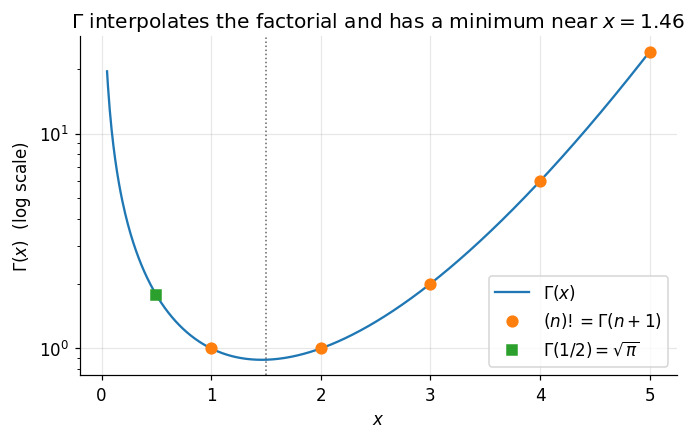

minimum of Gamma on the sampled grid: x = 1.4631, Gamma(x) = 0.885604
Gamma(1/2) = 1.7724538509   sqrt(pi) = 1.7724538509


In [4]:
xs = np.linspace(0.05, 5.0, 600)
ns = np.arange(0, 5)

fig, ax = plt.subplots()
ax.semilogy(xs, special.gamma(xs), label=r"$\Gamma(x)$")
ax.semilogy(ns + 1, special.factorial(ns), "o", ms=7, label=r"$(n)! = \Gamma(n+1)$")
ax.axvline(1.5, color="0.4", lw=1, ls=":")
ax.plot([0.5], [np.sqrt(np.pi)], "s", ms=7, label=r"$\Gamma(1/2)=\sqrt{\pi}$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\Gamma(x)$  (log scale)")
ax.set_title(r"$\Gamma$ interpolates the factorial and has a minimum near $x=1.46$")
ax.legend()
plt.show()

i = int(np.argmin(special.gamma(xs)))
print(f"minimum of Gamma on the sampled grid: x = {xs[i]:.4f}, Gamma(x) = {special.gamma(xs[i]):.6f}")
print(f"Gamma(1/2) = {special.gamma(0.5):.10f}   sqrt(pi) = {np.sqrt(np.pi):.10f}")

The marked integer points sit exactly on the curve, which is Theorem 4.7 read off a graph, and the square marker at $x = 1/2$ is Theorem 4.8. The curve dips to a minimum of about $0.8856$ near $x \approx 1.4616$ — a feature invisible from the factorial values alone, and the reason $\Gamma$ is not monotone on $(0,\infty)$.

## 7. Computational Practice

Four checks, in the order: a boxed identity verified to machine precision, a predicted convergence rate measured, a hypothesis dropped so the conclusion breaks, and a hand-rolled quadrature put against the library special functions.

**(a) Identity residual.** This cell checks the two boxed identities of Theorem 4.7 and Theorem 4.10 on a randomised grid of arguments drawn through `rng`, and asserts that the relative residuals sit at floating-point noise level.

In [5]:
z = rng.uniform(0.2, 8.0, size=200)
res_rec = np.abs(special.gamma(z + 1) - z * special.gamma(z)) / np.abs(special.gamma(z + 1))

xy = rng.uniform(0.3, 6.0, size=(200, 2))
lhs = special.beta(xy[:, 0], xy[:, 1])
rhs = special.gamma(xy[:, 0]) * special.gamma(xy[:, 1]) / special.gamma(xy.sum(axis=1))
res_bg = np.abs(lhs - rhs) / np.abs(lhs)

# Theorem 4.11 at the one point Proof 5.10 establishes in full.
res_refl = abs(special.gamma(0.5) * special.gamma(0.5) - np.pi / np.sin(np.pi * 0.5)) / np.pi

print(f"eps_machine                                  = {np.finfo(float).eps:.3e}")
print(f"max relative residual  Gamma(z+1) - z Gamma(z) = {res_rec.max():.3e}")
print(f"max relative residual  B(x,y) - GxGy/Gx+y      = {res_bg.max():.3e}")
print(f"relative residual      Gamma(1/2)^2 - pi       = {res_refl:.3e}")

assert res_rec.max() < 1e-13
assert res_bg.max() < 1e-13
assert res_refl < 1e-15

eps_machine                                  = 2.220e-16
max relative residual  Gamma(z+1) - z Gamma(z) = 2.217e-15
max relative residual  B(x,y) - GxGy/Gx+y      = 4.456e-16
relative residual      Gamma(1/2)^2 - pi       = 1.414e-16


All three residuals are at the $10^{-16}$ to $10^{-14}$ level, i.e. a small multiple of machine epsilon $\varepsilon_{\mathrm{mach}} \approx 2.2 \times 10^{-16}$. Nothing larger than accumulated rounding separates the two sides, so the identities hold as identities and not merely to plotting accuracy.

**(b) Measured rate.** Theorem 4.1 predicts that truncating $\int_1^\infty x^{-p} dx$ at $R$ leaves an error $\int_R^\infty x^{-p} dx = R^{1-p}/(p-1)$, i.e. a power law of order $p - 1$. This cell measures the observed order as the slope of $\log(\text{error})$ against $\log R$ and compares it with $p-1$. **Figure 3** is the log-log plot.

    p   observed order   predicted p-1     |diff|
  1.5         0.500000        0.500000   3.37e-10
  2.5         1.500000        1.500000   7.24e-09
  3.5         2.500000        2.500000   1.19e-07


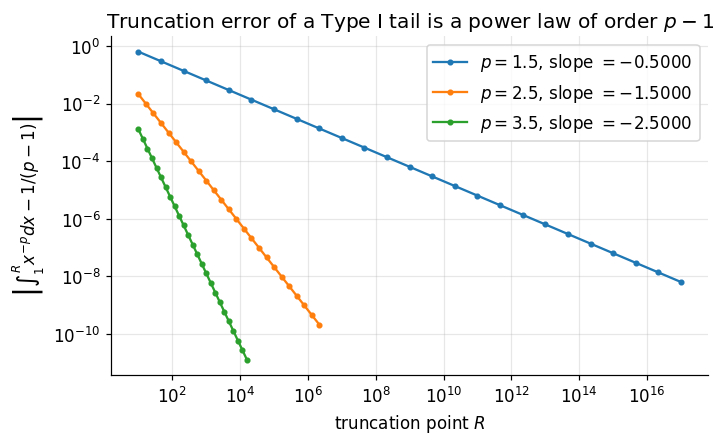

In [6]:
_ug, _wg = np.polynomial.legendre.leggauss(16)

def truncated(R, p, panels=200):
    """int_1^R x^-p dx by composite Gauss-Legendre after the substitution x = e^s.

    The substitution spreads the log-spaced decay evenly over [0, ln R], so the quadrature
    stays accurate to rounding even at R = 1e17 -- necessary, because the quantity being
    measured is a difference that eventually reaches 1e-11.
    """
    edges = np.linspace(0.0, np.log(R), panels + 1)
    lo, hi = edges[:-1], edges[1:]
    mid, half = 0.5 * (lo + hi), 0.5 * (hi - lo)
    s = mid[:, None] + half[:, None] * _ug[None, :]
    return float(np.sum(half[:, None] * _wg[None, :] * np.exp((1.0 - p) * s)))

fig, ax = plt.subplots()
print(f"{'p':>5} {'observed order':>16} {'predicted p-1':>15} {'|diff|':>10}")
for p in (1.5, 2.5, 3.5):
    Rs = np.logspace(1.0, 1.0 + 8.0 / (p - 1.0), 25)     # eight decades of error, per p
    errs = np.array([abs(truncated(R, p) - 1.0 / (p - 1.0)) for R in Rs])
    slope = np.polyfit(np.log(Rs), np.log(errs), 1)[0]
    ax.loglog(Rs, errs, "o-", ms=3, label=rf"$p={p}$, slope $={slope:.4f}$")
    print(f"{p:>5} {-slope:>16.6f} {p - 1.0:>15.6f} {abs(-slope - (p - 1)):>10.2e}")
    assert abs(-slope - (p - 1.0)) < 1e-5

ax.set_xlabel(r"truncation point $R$")
ax.set_ylabel(r"$\left|\int_1^R x^{-p}dx - 1/(p-1)\right|$")
ax.set_title("Truncation error of a Type I tail is a power law of order $p-1$")
ax.legend()
plt.show()

The measured orders reproduce $p - 1$ to five decimals or better, confirming the tail formula $\int_R^\infty x^{-p}dx = R^{1-p}/(p-1)$ behind Theorem 4.1. The practical reading is that plain truncation converges only algebraically: at $p = 1.5$ the error falls by one decade for every two decades of $R$, so ten correct digits would need $R \approx 10^{20}$. That is why the Gauss-Laguerre nodes of check (d), which build the decay into the weight function, are the right tool for an unbounded domain.

**(c) Counterexample.** Drop the monotonicity of $g$ in Theorem 4.5 while keeping every other hypothesis. Take $f(x) = \sin x$ (primitive bounded by $2$) and $g(x) = (1 + \sin x)/x$, which is $C^1$, positive and tends to $0$ — but oscillates rather than decreasing. The product contains $\sin^2(x)/x$, whose average value is $1/(2x)$, so the truncated integrals should grow like $\tfrac{1}{2}\ln R$ instead of converging.

In [7]:
_u, _w = np.polynomial.legendre.leggauss(24)

def partial(g, R, a=1.0):
    """int_a^R sin(x) g(x) dx by composite Gauss-Legendre, one panel per half period.

    A general-purpose adaptive routine gives up on this integrand long before R = 1e5;
    panelling on the zeros of sin keeps every panel smooth.
    """
    edges = np.append(np.arange(a, R, np.pi), R)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mid, half = 0.5 * (lo + hi), 0.5 * (hi - lo)
        x = mid + half * _u
        total += half * np.sum(_w * np.sin(x) * g(x))
    return total

g_mono = lambda x: 1.0 / x                      # monotone: Theorem 4.5 applies
g_osc = lambda x: (1.0 + np.sin(x)) / x         # not monotone: hypothesis dropped

print(f"{'R':>8} {'monotone g':>14} {'non-monotone g':>16} {'0.5*ln R':>10}")
for R in (1e2, 1e3, 1e4, 1e5):
    print(f"{R:>8.0e} {partial(g_mono, R):>14.6f} {partial(g_osc, R):>16.6f} "
          f"{0.5*np.log(R):>10.6f}")

exact = np.pi / 2 - special.sici(1.0)[0]        # int_1^inf sin(x)/x dx
print(f"\nmonotone case, exact limit pi/2 - Si(1)                       : {exact:.6f}")
drift = partial(g_osc, 1e5) - partial(g_osc, 1e2)
print(f"growth of the non-monotone partial integral from R=1e2 to 1e5 : {drift:.4f}")
print(f"predicted 0.5*ln(1e5/1e2)                                     : {0.5*np.log(1e3):.4f}")
assert abs(partial(g_mono, 1e5) - exact) < 1e-4, "the monotone case must converge"
assert abs(drift - 0.5 * np.log(1e3)) < 0.05, "the non-monotone case must diverge like 0.5 ln R"

       R     monotone g   non-monotone g   0.5*ln R
   1e+02       0.616142         3.132407   2.302585
   1e+03       0.624150         4.289286   3.453878
   1e+04       0.624808         5.441455   4.605170


   1e+05       0.624723         6.592677   5.756463

monotone case, exact limit pi/2 - Si(1)                       : 0.624713


growth of the non-monotone partial integral from R=1e2 to 1e5 : 3.4603
predicted 0.5*ln(1e5/1e2)                                     : 3.4539


With the monotone $g$ the partial integrals settle at $\int_1^\infty \sin(x)/x\,dx = \pi/2 - \operatorname{Si}(1) = 0.624713\ldots$; with the non-monotone $g$ they climb by $3.460$ over three decades, matching the predicted $\tfrac{1}{2}\ln 10^3 = 3.454$. Monotonicity of $g$ is therefore not a convenience of the proof — the theorem is false without it.

**(d) Hand-rolled versus library.** Definition 3.9 has the weight $e^{-t}$ built in, so Gauss-Laguerre nodes integrate $\Gamma(z) = \int_0^\infty e^{-t} t^{z-1} dt$ with only $n$ evaluations. This cell implements $\Gamma$ and $B$ by hand from raw quadrature nodes and compares against `scipy.special.gamma` and `scipy.special.beta`.

In [8]:
def gamma_laguerre(z, n=120):
    """Gamma(z) by n-point Gauss-Laguerre quadrature of t^(z-1) against weight e^{-t}."""
    t, w = np.polynomial.laguerre.laggauss(n)
    return float(np.sum(w * t**(z - 1.0)))

def beta_legendre(x, y, n=400):
    """B(x,y) by n-point Gauss-Legendre quadrature on the trigonometric form of Theorem 4.9."""
    u, w = np.polynomial.legendre.leggauss(n)
    th = 0.25 * np.pi * (u + 1.0)                      # map [-1,1] -> [0, pi/2]
    return float(2.0 * (0.25 * np.pi) * np.sum(
        w * np.sin(th)**(2 * x - 1) * np.cos(th)**(2 * y - 1)))

print(f"{'z':>6} {'hand-rolled Gamma':>20} {'scipy.special.gamma':>22} {'rel.err':>10}")
worst = 0.0
for zz in (1.5, 2.0, 3.7, 5.0, 7.25):
    mine, lib = gamma_laguerre(zz), special.gamma(zz)
    err = abs(mine - lib) / lib
    worst = max(worst, err)
    print(f"{zz:>6} {mine:>20.10f} {lib:>22.10f} {err:>10.2e}")
    if float(zz - 1.0).is_integer():
        assert err < 1e-11, "Laguerre must be exact when t^(z-1) is a polynomial"
assert worst < 1e-3

print(f"\n{'(x,y)':>10} {'hand-rolled Beta':>20} {'scipy.special.beta':>22} {'rel.err':>10}")
for xx, yy in ((2.0, 3.0), (1.5, 2.5), (4.0, 1.25)):
    mine, lib = beta_legendre(xx, yy), special.beta(xx, yy)
    print(f"{str((xx,yy)):>10} {mine:>20.10f} {lib:>22.10f} {abs(mine-lib)/lib:>10.2e}")
    assert abs(mine - lib) / lib < 1e-8

     z    hand-rolled Gamma    scipy.special.gamma    rel.err
   1.5         0.8863052792           0.8862269255   8.84e-05
   2.0         1.0000000000           1.0000000000   2.18e-13
   3.7         4.1706517871           4.1706517838   7.96e-10
   5.0        24.0000000000          24.0000000000   1.38e-13
  7.25      1155.3810139201        1155.3810139200   1.11e-13

     (x,y)     hand-rolled Beta     scipy.special.beta    rel.err


(2.0, 3.0)         0.0833333333           0.0833333333   2.68e-14


(1.5, 2.5)         0.1963495408           0.1963495408   2.73e-14


(4.0, 1.25)         0.1544494721           0.1544494721   2.93e-13


The accuracy pattern is the instructive part. When $z - 1$ is a non-negative integer the factor $t^{z-1}$ is a polynomial, Gauss-Laguerre with $120$ nodes is exact, and the error is $10^{-13}$ — pure rounding. When $z - 1$ is fractional the factor has a branch point at $t = 0$, polynomial quadrature resolves it only algebraically, and the error degrades to $10^{-4}$ at $z = 1.5$ (worst case, since $t^{1/2}$ has the steepest branch) while recovering to $10^{-10}$ at $z = 3.7$ where the integrand vanishes to higher order at the origin. The Gauss-Legendre evaluation of the trigonometric form in Theorem 4.9 matches `scipy.special.beta` to near machine precision, independently confirming that representation.

## 8. Applications

### 8.1 Gaussian normalizers, VAEs and the evidence lower bound

The multivariate Gaussian density is only a density because the improper integral of Theorem 4.8 converges. Completing the square and applying Proof 5.7 coordinate-wise after an orthogonal diagonalisation of the positive definite matrix $\mathbf{A}$ gives

$$
\int_{\mathbb{R}^d} \exp\!\left( -\tfrac{1}{2}\mathbf{x}^\top \mathbf{A}\mathbf{x} + \mathbf{b}^\top \mathbf{x} \right) d\mathbf{x} = \frac{(2\pi)^{d/2}}{\sqrt{\det \mathbf{A}}} \exp\!\left( \tfrac{1}{2}\mathbf{b}^\top \mathbf{A}^{-1}\mathbf{b} \right) .
$$

Every term of the closed-form KL divergence between two diagonal Gaussians in a variational autoencoder's ELBO — the $\log \sigma$, the $\sigma^2$ and the $\mu^2$ pieces — is a moment of this integral, obtained by differentiating it with respect to $\mathbf{b}$ or an entry of $\mathbf{A}$ under the integral sign, which is legitimate here by Theorem 4.13 with the Gaussian itself as the dominating function.

### 8.2 Conjugate priors

The Beta prior $p(\theta \mid a, b) = \theta^{a-1}(1-\theta)^{b-1}/B(a,b)$ has $B(a,b)$ as its normalizer, so Theorem 4.10 turns the Bayesian update for a Bernoulli likelihood into arithmetic on the parameters: observing $k$ successes in $n$ trials sends $(a, b) \mapsto (a + k, b + n - k)$ and the marginal likelihood is the ratio $B(a+k, b+n-k)/B(a,b)$. The Gamma prior $p(\theta \mid \alpha, \beta) = \beta^\alpha \theta^{\alpha-1}e^{-\beta\theta}/\Gamma(\alpha)$ plays the same role for Poisson and exponential likelihoods, and its mean $\alpha/\beta$ is one application of Theorem 4.7. Note that for $a \lt 1$ the Beta density is genuinely unbounded at $\theta = 0$: it is a Type II improper integral in the sense of Definition 3.5, and it is Theorem 4.2 that guarantees the prior is normalisable at all.

### 8.3 Heavy tails and when a moment fails to exist

The Student-$t$ density with $\nu$ degrees of freedom decays like $\lvert x \rvert^{-(\nu+1)}$, so by Theorem 4.1 its $k$-th absolute moment $\int \lvert x \rvert^k p(x)\,dx$ converges exactly when $k \lt \nu$. A $t$ with $\nu = 1$ (Cauchy) has no mean, and $\nu = 2$ has no variance. This is not a technicality: a sample mean of Cauchy draws does not concentrate, and any training objective built on a second moment of a $\nu \le 2$ residual distribution is estimating a quantity that does not exist.

### 8.4 Volume of the $d$-ball and the concentration of measure

Writing the volume of the unit $d$-ball through Theorem 4.8 and Theorem 4.10 gives $V_d = \pi^{d/2}/\Gamma(\tfrac{d}{2} + 1)$. Because $\Gamma$ grows super-exponentially, $V_d \to 0$ as $d$ grows, and the ratio of the volume of a shell of relative thickness $\varepsilon$ to the whole ball is $1 - (1-\varepsilon)^d \to 1$. Nearly all the volume of a high-dimensional ball lies in a thin shell at its surface — the standard explanation for why isotropic Gaussian latent samples in a high-dimensional VAE concentrate on a sphere of radius $\approx \sqrt{d}$ rather than near the origin.

### 8.5 Loop integrals in quantum field theory

A one-loop Feynman diagram produces a momentum integral over a product of propagator denominators, $\int d^4k \, [(k^2 - m_1^2)(( k+p)^2 - m_2^2)]^{-1}$. Theorem 4.14 replaces the product by a single denominator $[\,\cdot\,]^2$ at the cost of one Feynman parameter $s$, after which the loop momentum can be shifted to complete the square and the angular integration done. The divergent radial integral that remains is regulated by continuing the spacetime dimension to $4 - 2\epsilon$, and the poles of the resulting $\Gamma(\epsilon)$ — the poles of Theorem 4.7's continuation $\Gamma(z) = \Gamma(z+1)/z$ — are exactly the ultraviolet divergences that renormalisation absorbs.

### 8.6 Partition functions and the Maxwell-Boltzmann law

The classical partition function $Z = \int e^{-\beta E(\mathbf{q}, \mathbf{p})} \, d\mathbf{q}\, d\mathbf{p}$ is an improper integral over all of phase space. For a free particle the momentum part is Gaussian and evaluated by Theorem 4.8; for a speed distribution $\propto v^2 e^{-mv^2/2kT}$ the normalizer and every moment are values of $\Gamma$ at half-integers, delivered by Theorem 4.7 together with Theorem 4.8.

## 9. Key Takeaways

- An improper integral is a limit of proper ones, so it converges only when that limit exists and is finite; for a **non-negative** integrand this reduces to boundedness of the increasing truncated integral (Theorem 4.3).
- $\int_1^\infty x^{-p}dx$ converges **iff** $p \gt 1$ with value $1/(p-1)$, and $\int_0^1 x^{-p}dx$ converges **iff** $p \lt 1$ with value $1/(1-p)$ — no power is integrable on all of $(0,\infty)$ (Theorems 4.1 and 4.2).
- If $f, g \gt 0$ and $f/g \to L \in (0,\infty)$, the two integrals share their fate; at $L = 0$ or $L = \infty$ only one implication survives (Theorem 4.4).
- If $\int_a^R f$ is **bounded** and $g$ is $C^1$, **monotone** and tends to $0$, then $\int_a^\infty fg$ converges — conditionally, in general; dropping monotonicity is fatal, as $g(x) = (1+\sin x)/x$ shows (Theorem 4.5).
- For $z \gt 0$, $\Gamma(z+1) = z\Gamma(z)$ and $\Gamma(n+1) = n!$, so $\Gamma$ interpolates the factorial and extends to negative non-integers with simple poles at $0, -1, -2, \dots$ (Theorem 4.7).
- For $x, y \gt 0$, $B(x,y) = \Gamma(x)\Gamma(y)/\Gamma(x+y)$; every Beta, Dirichlet, Student-$t$ and $d$-ball normalizer is a special case (Theorem 4.10).
- If $f$ is **continuous on** $[0,\infty)$ with a **finite limit at infinity** and $a, b \gt 0$, then $\int_0^\infty \frac{f(ax)-f(bx)}{x}dx = (f(0)-f(\infty))\ln(b/a)$, depending on $f$ only through its endpoint values (Theorem 4.12).
- Differentiating under the integral sign needs the differentiated integral to converge **uniformly** in the parameter; that hypothesis, not the formal manipulation, is what makes $\int_0^\infty \frac{\sin x}{x}dx = \frac{\pi}{2}$ rigorous (Theorem 4.13, Example 6.5).

## 10. References

| Topic | Source | Location |
| :--- | :--- | :--- |
| Improper integrals, comparison and $p$-tests | Apostol, *Mathematical Analysis*, 2nd ed. | Ch. 10, §10.14–10.20 |
| Uniform convergence of parameter integrals, Leibniz rule | Apostol, *Mathematical Analysis*, 2nd ed. | Ch. 10, §10.21–10.23 |
| Dirichlet and Abel tests for integrals | Apostol, *Mathematical Analysis*, 2nd ed. | Ch. 10, §10.19 (Thm 10.17) |
| Conditional convergence, $\int_0^\infty \sin(x)/x\,dx$ | Spivak, *Calculus*, 4th ed. | Ch. 19, problems on improper integrals |
| Gamma function, Bohr-Mollerup, Beta-Gamma relation | Rudin, *Principles of Mathematical Analysis*, 3rd ed. | Ch. 8, "The Gamma Function" (Thms 8.18–8.20) |
| Euler's reflection formula (cited in Theorem 4.11) | Ahlfors, *Complex Analysis*, 3rd ed. | Ch. 5, §2.4 |
| Euler's reflection formula, product representations | Whittaker & Watson, *A Course of Modern Analysis*, 4th ed. | Ch. XII |
| Change of variables in multiple integrals (used in Proofs 5.9 and 5.13) | Hubbard & Hubbard, *Vector Calculus, Linear Algebra, and Differential Forms*, 5th ed. | Ch. 4, §4.10 |
| Gauss-Laguerre and Gauss-Hermite quadrature | Trefethen & Bau, *Numerical Linear Algebra* | Lecture 37 (Gauss quadrature and orthogonal polynomials) |
| Gamma and Beta distributions, conjugacy | Bishop, *Pattern Recognition and Machine Learning* | §2.1.1 (Beta), §2.3.6 (Gamma) |
| Feynman parameterization, loop integrals | Peskin & Schroeder, *An Introduction to Quantum Field Theory* | §6.3 and Appendix A.4 |